In [12]:
# PHASE 2 

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [13]:
# Load Dataset
df = pd.read_csv("urban_water_dataset.csv")


In [14]:
print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Household_Size  Seasonal_Index  Garden_Area  Daily_Liters_Used
0               7            1.10           22              667.0
1               4            1.34           29              541.8
2               5            1.13           37              627.6
3               7            1.63           44              864.6
4               3            1.07           47              519.4


In [15]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1774 entries, 0 to 1773
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_Size     1774 non-null   int64  
 1   Seasonal_Index     1774 non-null   float64
 2   Garden_Area        1774 non-null   int64  
 3   Daily_Liters_Used  1774 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 55.6 KB
None


In [16]:
# Data Cleaning
df.fillna(df.mean(numeric_only=True), inplace=True)

In [17]:
# Features and Target used
X = df[['Household_Size', 'Seasonal_Index']]  
y = df['Daily_Liters_Used']


In [18]:
# Train-test split (controlled randomness)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10
)

In [19]:
# Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
# Prediction
y_pred = model.predict(X_test)


In [21]:
# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("Accuracy:", round(r2 * 100, 2), "%")

R2 Score: 0.8110471430940482
MAE: 56.32757933744415
MSE: 4320.41634839206
Accuracy: 81.1 %


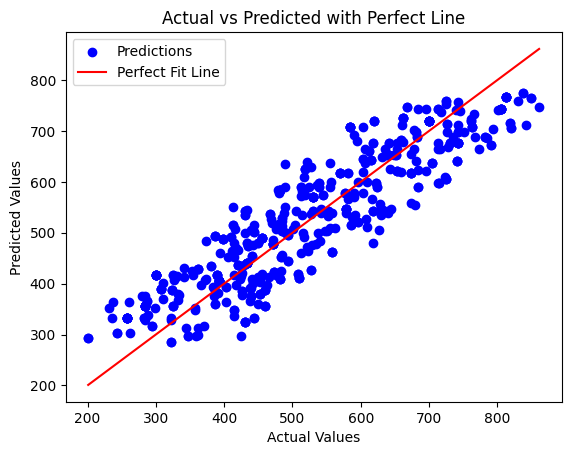

In [26]:
plt.figure()

# scatter points
plt.scatter(y_test, y_pred, color='blue', label="Predictions")

# straight perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', label="Perfect Fit Line")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted with Perfect Line")

plt.legend()
plt.show()

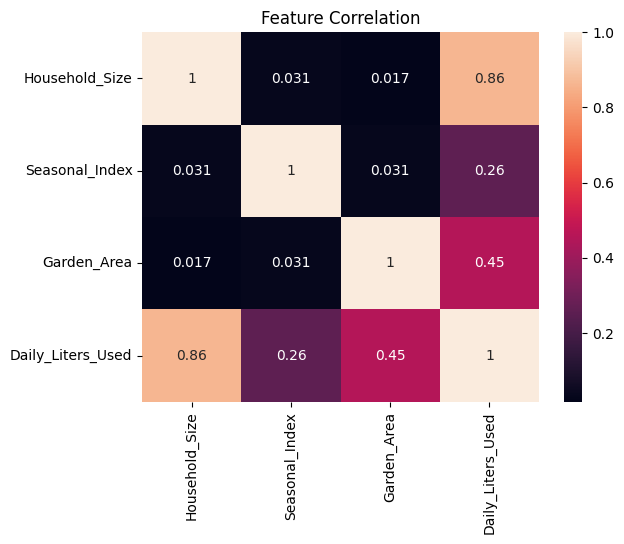

In [ ]:
# Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation")
plt.show()